<a href="https://colab.research.google.com/github/vis-hal-git/Blood-Cancer-Prediction/blob/main/BDC_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mehradaria/leukemia")

Using Colab cache for faster access to the 'leukemia' dataset.


In [ ]:
print(path)

/kaggle/input/leukemia


In [ ]:
import os
os.listdir(path)

['Segmented', 'Original']

In [ ]:
import os

base_dir = os.path.join(path, "Segmented")  # Recommended

In [ ]:
print(os.listdir(base_dir))

['Pro', 'Pre', 'Benign', 'Early']


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
import shutil
from sklearn.model_selection import train_test_split

base_dir = os.path.join(path, "Segmented")   # Recommended

new_base = "/content/leukemia_split"
os.makedirs(new_base, exist_ok=True)

for category in os.listdir(base_dir):
    category_path = os.path.join(base_dir, category)
    images = os.listdir(category_path)

    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)

    for split_name, split_data in zip(["train","val","test"], [train,val,test]):
        split_folder = os.path.join(new_base, split_name, category)
        os.makedirs(split_folder, exist_ok=True)

        for img in split_data:
            shutil.copy(
                os.path.join(category_path, img),
                os.path.join(split_folder, img)
            )

print("Dataset Split Completed")

Dataset Split Completed


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_dir = os.path.join(new_base, "train")
val_dir = os.path.join(new_base, "val")
test_dir = os.path.join(new_base, "test")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2277 images belonging to 4 classes.
Found 489 images belonging to 4 classes.
Found 490 images belonging to 4 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.6171875), 1: np.float64(0.8261973875181422), 2: np.float64(0.8445845697329377), 3: np.float64(1.012900355871886)}


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,068 (9.89 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.6174 - loss: 1.3120

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


72/72 ━━━━━━━━━━━━━━━━━━━━ 88s 805ms/step - accuracy: 0.6188 - loss: 1.3065 - val_accuracy: 0.8793 - val_loss: 0.4387 - learning_rate: 1.0000e-04
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - accuracy: 0.8569 - loss: 0.4615

72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 377ms/step - accuracy: 0.8571 - loss: 0.4607 - val_accuracy: 0.9284 - val_loss: 0.2495 - learning_rate: 1.0000e-04
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9055 - loss: 0.3028

...

72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 386ms/step - accuracy: 0.9498 - loss: 0.1314 - val_accuracy: 0.9611 - val_loss: 0.1125 - learning_rate: 1.0000e-04
Epoch 13/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 379ms/step - accuracy: 0.9587 - loss: 0.1201 - val_accuracy: 0.9550 - val_loss: 0.1293 - learning_rate: 1.0000e-04
Epoch 14/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9626 - loss: 0.1270

72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 383ms/step - accuracy: 0.9626 - loss: 0.1270 - val_accuracy: 0.9652 - val_loss: 0.1113 - learning_rate: 1.0000e-04
Epoch 15/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 393ms/step - accuracy: 0.9641 - loss: 0.1182 - val_accuracy: 0.9652 - val_loss: 0.1120 - learning_rate: 1.0000e-04
Epoch 16/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.9601 - loss: 0.1177

72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 387ms/step - accuracy: 0.9601 - loss: 0.1176 - val_accuracy: 0.9673 - val_loss: 0.1070 - learning_rate: 1.0000e-04
Epoch 17/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 381ms/step - accuracy: 0.9563 - loss: 0.1237 - val_accuracy: 0.9611 - val_loss: 0.1138 - learning_rate: 1.0000e-04
Epoch 18/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 375ms/step - accuracy: 0.9746 - loss: 0.0850 - val_accuracy: 0.9652 - val_loss: 0.1115 - learning_rate: 1.0000e-04
Epoch 19/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.9673 - loss: 0.1043

72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 396ms/step - accuracy: 0.9673 - loss: 0.1044 - val_accuracy: 0.9652 - val_loss: 0.1033 - learning_rate: 1.0000e-04
Epoch 20/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.9573 - loss: 0.1178

72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 392ms/step - accuracy: 0.9574 - loss: 0.1176 - val_accuracy: 0.9734 - val_loss: 0.0917 - learning_rate: 1.0000e-04


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 599ms/step - accuracy: 0.8371 - loss: 0.4304 - val_accuracy: 0.9714 - val_loss: 0.0903
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 386ms/step - accuracy: 0.9147 - loss: 0.2555 - val_accuracy: 0.9202 - val_loss: 0.2196
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 381ms/step - accuracy: 0.9204 - loss: 0.2273 - val_accuracy: 0.9100 - val_loss: 0.3127
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 382ms/step - accuracy: 0.9162 - loss: 0.2353 - val_accuracy: 0.8978 - val_loss: 0.3836
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 27s 381ms/step - accuracy: 0.9363 - loss: 0.2075 - val_accuracy: 0.8978 - val_loss: 0.3691
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 390ms/step - accuracy: 0.9334 - loss: 0.2199 - val_accuracy: 0.8998 - val_loss: 0.3668
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 393ms/step - accuracy: 0.9523 - loss: 0.1528 - val_accuracy: 0.9039 - val_loss: 0.3308
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 28s 390ms/step - accuracy: 0.9390 - loss: 0.1652 - val_accu

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 18s 868ms/step
              precision    recall  f1-score   support

           0       0.98      0.63      0.77        76
           1       0.77      0.99      0.87       148
           2       0.99      0.90      0.94       145
           3       0.99      0.98      0.99       121

    accuracy                           0.91       490
   macro avg       0.93      0.88      0.89       490
weighted avg       0.92      0.91      0.90       490



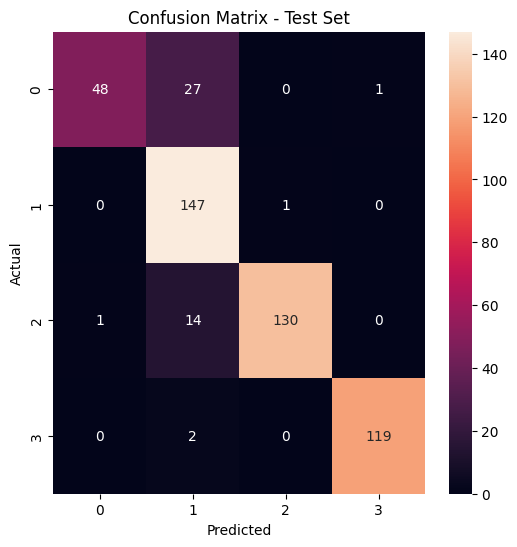

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_gen.reset()
pred = model.predict(test_gen)
y_pred = np.argmax(pred, axis=1)

print(classification_report(test_gen.classes, y_pred))

cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

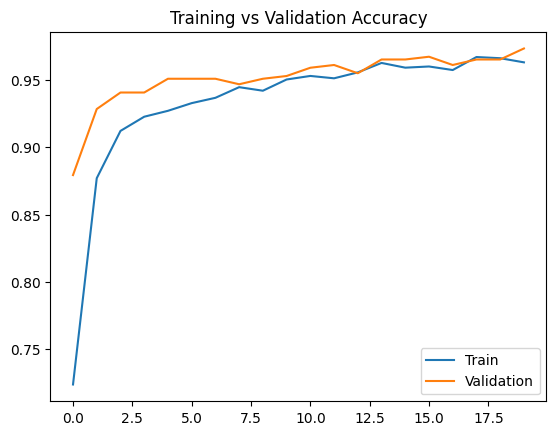

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()